# DR Real-Side Travel Time Plots

This notebook reads the copied domain-randomization transition logs from `logs/sim2real_transitions/presslight` and plots the real-side average travel time for each network.

Note: these logs do not contain a literal `REAL_TRAIN` tag. The real-side series is recorded as:

- `TEST_REAL` during training
- `TRAIN_REAL` after episode `1000`

The plots below use `TEST_REAL` for the intermediate checkpoints and `TRAIN_REAL` only for episode `1000`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOG_ROOT = Path("logs/sim2real_transitions/presslight")

NETWORK_ORDER = [
    "bullhead_1",
    "bullhead_3",
    "cologne1",
    "cologne3",
    "hz1x1",
    "hz4x4",
    "ingolstadt1",
    "ingolstadt7",
    "tempe_16",
    "tempe_1x1",
]

COLUMNS = [
    "exp_name",
    "mode",
    "episode",
    "travel_time",
    "aux",
    "reward",
    "queue",
    "delay",
    "throughput",
]


In [2]:
def load_network_real_series(network: str) -> pd.DataFrame:
    setting_dir = LOG_ROOT / network / "domain_randomization" / "setting4"
    dtl_logs = sorted(setting_dir.glob("*_DTL.log"))
    if not dtl_logs:
        return pd.DataFrame(columns=COLUMNS + ["network", "log_path"])

    log_path = dtl_logs[0]
    df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
    df["network"] = network
    df["log_path"] = str(log_path)
    df = df[df["mode"].isin(["TEST_REAL", "TRAIN_REAL"])].copy()
    df["episode"] = pd.to_numeric(df["episode"], errors="coerce")
    df["travel_time"] = pd.to_numeric(df["travel_time"], errors="coerce")

    # Use TEST_REAL for the in-training checkpoints and TRAIN_REAL only at episode 1000.
    test_df = df[df["mode"] == "TEST_REAL"].copy()
    post_df = df[(df["mode"] == "TRAIN_REAL") & (df["episode"] == 1000)].copy()
    series_df = pd.concat([test_df, post_df], ignore_index=True)
    series_df = series_df.drop_duplicates(subset=["episode"], keep="last")
    series_df = series_df.sort_values("episode").reset_index(drop=True)
    return series_df


real_series = {network: load_network_real_series(network) for network in NETWORK_ORDER}

summary_rows = []
for network, df in real_series.items():
    summary_rows.append(
        {
            "network": network,
            "points": len(df),
            "episodes": list(df["episode"]) if not df.empty else [],
            "log_path": df["log_path"].iloc[0] if not df.empty else "",
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df


,network,points,episodes,log_path
0,bullhead_1,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/bullhead_...
1,bullhead_3,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/bullhead_...
2,cologne1,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/cologne1/...
3,cologne3,1,[1000],logs/sim2real_transitions/presslight/cologne3/...
4,hz1x1,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/hz1x1/dom...
5,hz4x4,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/hz4x4/dom...
6,ingolstadt1,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/ingolstad...
7,ingolstadt7,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/ingolstad...
8,tempe_16,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/tempe_16/...
9,tempe_1x1,10,"[100, 200, 300, 400, 500, 600, 700, 800, 900, ...",logs/sim2real_transitions/presslight/tempe_1x1...


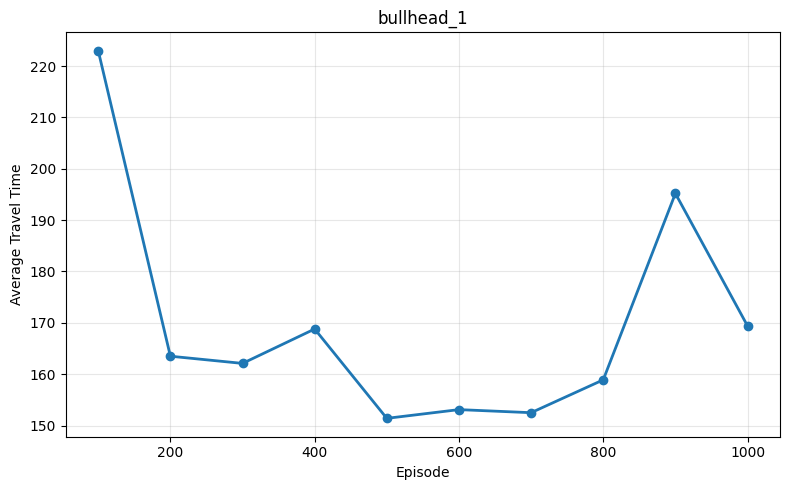

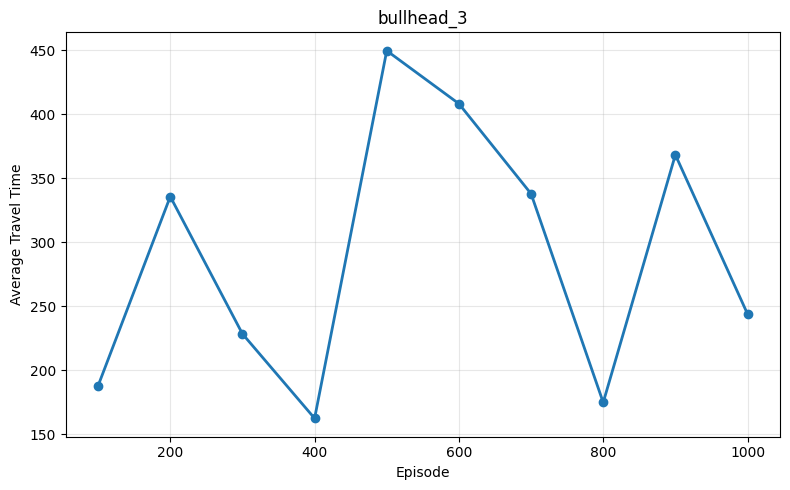

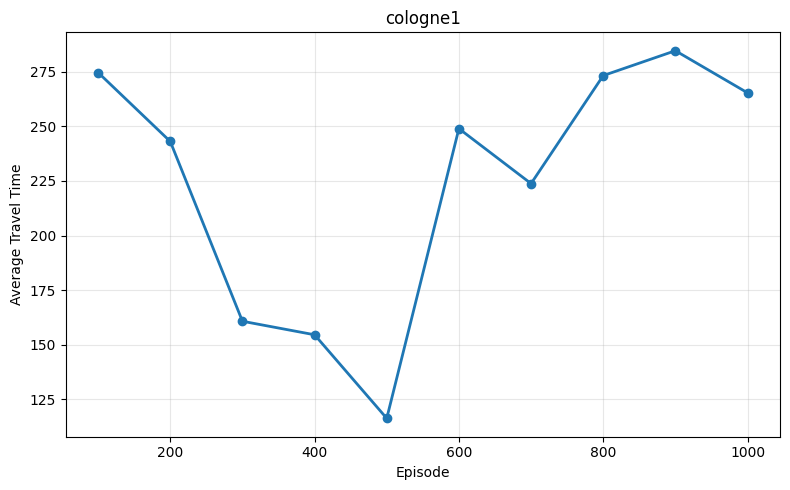

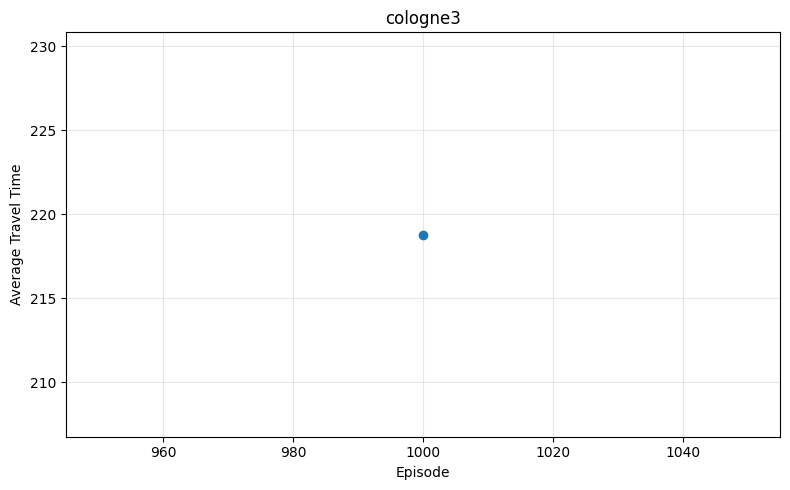

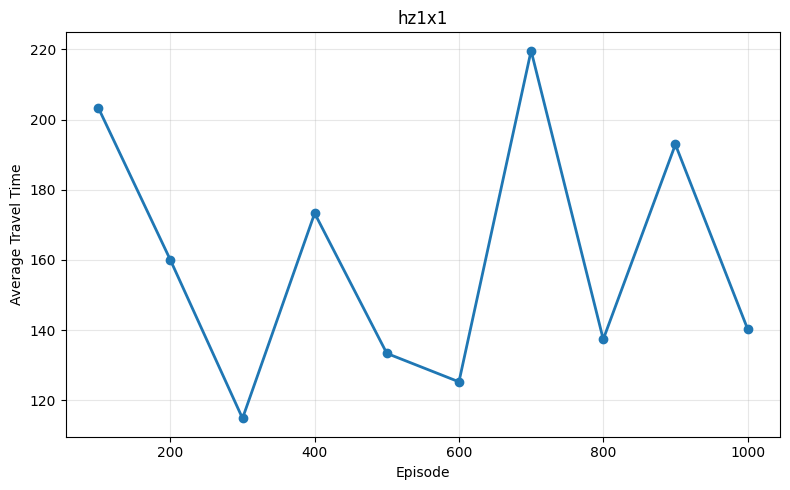

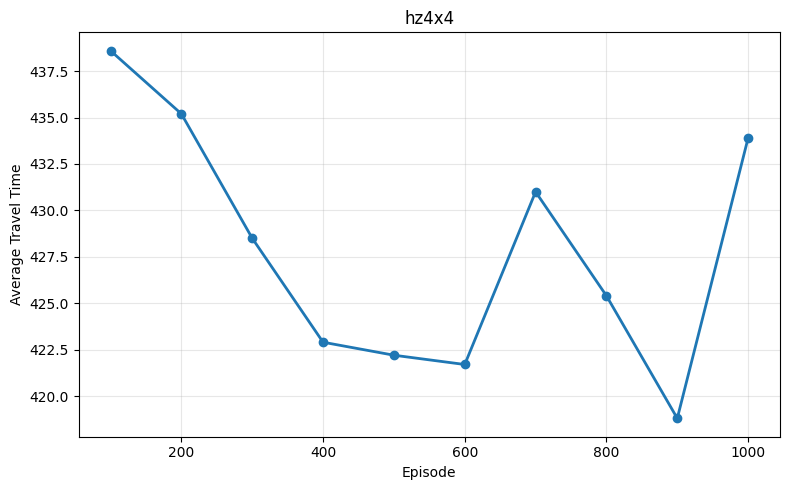

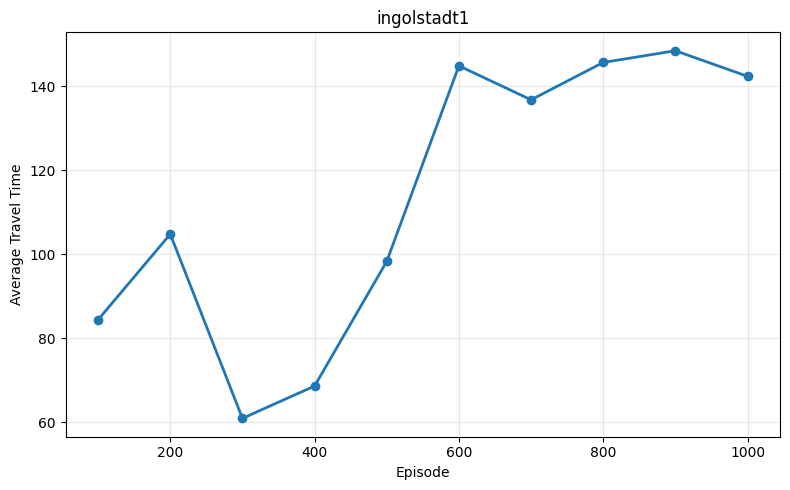

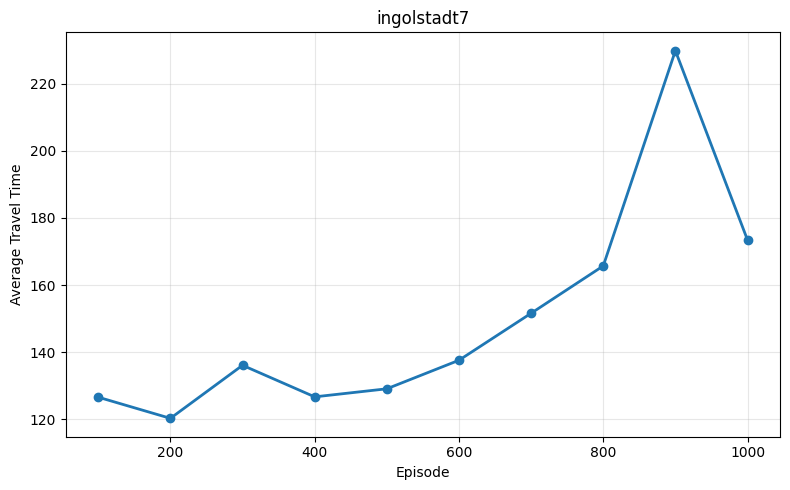

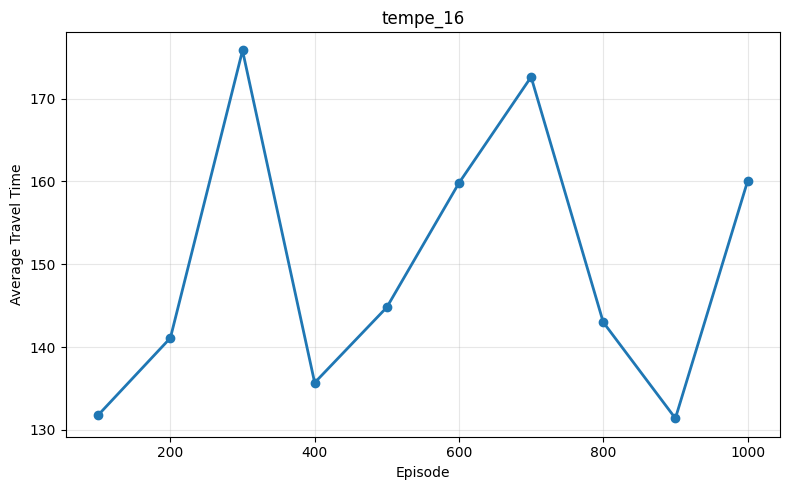

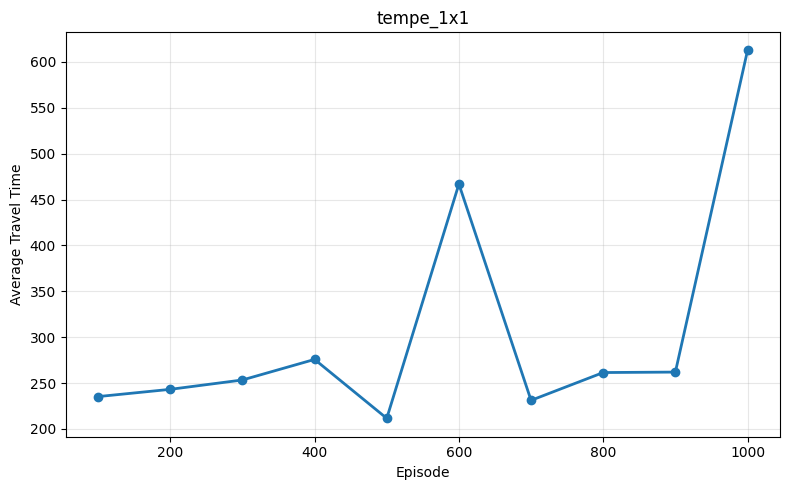

In [3]:
for network in NETWORK_ORDER:
    fig, ax = plt.subplots(figsize=(8, 5))
    df = real_series[network]
    ax.set_title(network)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Average Travel Time")
    ax.grid(True, alpha=0.3)

    if df.empty:
        ax.text(
            0.5,
            0.5,
            "No real-side rows found",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        fig.tight_layout()
        plt.show()
        continue

    ax.plot(
        df["episode"],
        df["travel_time"],
        marker="o",
        linewidth=2,
    )
    fig.tight_layout()
    plt.show()
